# Deep Q-Network (DQN)

* Full Name: Radin Cheraghi


In [1]:
import sys
print(sys.executable)

c:\Users\ideapad 5\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
%pip install "gymnasium[classic-control]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install "gymnasium[box2d]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random
import matplotlib.pyplot as plt
import gymnasium as gym

In [5]:
# MP4 Libraries
from IPython.display import HTML
from base64 import b64encode
import cv2
import numpy as np

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Helper Functions for Video

Function to convert MP4 to displayable HTML5 video and display


In [9]:
def show_video(video_path, width=480):
    with open(video_path, "rb") as f:
        video_data = f.read()
    encoded = b64encode(video_data).decode("utf-8")
    html = f'''
        <video width="{width}" controls>
            <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
        </video>
    '''
    return HTML(html)

# def save_agent_video(env, agent, filename="media/agent_demo.mp4"):
#     frames = []
#     state, _ = env.reset()
#     done = False

#     while not done:
#         action = agent.select_action(state)
#         next_state, reward, terminated, truncated, info = env.step(action)
#         done = terminated or truncated
#         frames.append(env.render())
#         state = next_state

#     height, width, layers = frames[0].shape
#     out = cv2.VideoWriter(
#         filename, cv2.VideoWriter_fourcc(*"mp4v"), 30, (width, height)
#     )
#     for f in frames:
#         out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
#     out.release()

def save_agent_video(env, agent, filename="media/agent_demo.mp4"):
    frames = []
    state, _ = env.reset(seed=SEED)
    done = False

    while not done:
        action = agent.select_action(state, training=False)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        state = next_state

    height, width, layers = frames[0].shape
    out = cv2.VideoWriter(
        filename, cv2.VideoWriter_fourcc(*"mp4v"), 30, (width, height)
    )

    for f in frames:
        out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))

    out.release()
    return filename

### Checkout the Environment


In [ ]:
ENV_ID = "LunarLander-v3"

try:
    env = gym.make(ENV_ID, render_mode="rgb_array")
except Exception:
    ENV_ID = "LunarLander-v2"
    env = gym.make(ENV_ID, render_mode="rgb_array")

env.action_space.seed(SEED)

print("Environment:", ENV_ID)
print("Action space:", env.action_space)
print("Action space dim:", env.action_space.n)
print("Observation space:", env.observation_space)
print("Observation space dim:", env.observation_space.shape[0])

# Random rollout and visualize
frames = []
state, _ = env.reset(seed=SEED)
done = False

while not done:
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    frames.append(env.render())
    state = next_state

random_video_path = "media/random_rollout.mp4"

height, width, layers = frames[0].shape
out = cv2.VideoWriter(
    random_video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    30,
    (width, height)
)

for frame in frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

out.release()

show_video(random_video_path, width=600)

Environment: LunarLander-v3
Action space: Discrete(4)
Action space dim: 4
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Observation space dim: 8


### Replay Buffer
In DQN, the agent learns from past experiences.  
This buffer stores transitions in the form of (state, action, reward, next_state, done).

+ Your task: complete the `push` and `sample` methods.

- `push` should add a new Transition into the buffer.
- `sample` should randomly return a batch of transitions  
  (this helps break correlations and stabilize learning).


In [11]:
Transition = namedtuple(
    "Transition",
    ["state", "action", "reward", "next_state", "done"]
)

class ReplayBuffer:
    """Stores experiences for experience replay"""
    def __init__(self, capacity: int = 100):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size: int) -> Transition:
        transitions = random.sample(self.buffer, batch_size)
        return Transition(*zip(*transitions))
    
    def __len__(self):
        return len(self.buffer)

### Q-Network


In [12]:
class QNetwork(nn.Module):
    """Simple neural network to approximate Q(s,a)"""
    def __init__(self, state_dim: int, action_dim: int):
        super(QNetwork, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    
    def forward(self, x):
        return self.network(x)

###  Hyperparameters of the DQN Agent
These values control exploration, learning stability, and update frequency.
Feel free to experiment — small changes can significantly affect performance.

- `gamma`: discount factor  
- `epsilon`: initial exploration rate  
- `epsilon_decay`: how fast the agent shifts from exploration to exploitation  
- `batch_size`: number of samples from ReplayBuffer for each update  
- `target_update_freq`: how often the target network is updated


### Action Selection (Epsilon-Greedy)

The agent chooses between:
- exploration (random action) with probability epsilon  
- exploitation (best predicted action) otherwise


### Update Step of DQN

This is the heart of the algorithm:
1. Sample a batch from ReplayBuffer  
2. Compute predicted Q-values (current network)  
3. Compute target Q-values (target network)  
4. Calculate loss  
5. Optimize network weights  
6. Periodically update the target network

+ Your task: fill in the missing steps and complete the TODOs.
Follow the comments carefully — they guide the flow of DQN training.


In [13]:
class DQNAgent:
    """
    Simple DQN Agent
    
    Key components:
    - Q-Network: approximates Q(s,a)
    - Target Network: provides stable targets for learning
    - Replay Buffer: stores past experiences
    - Epsilon-greedy: balances exploration/exploitation
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # Hyperparameters
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995
        self.batch_size = 64
        self.target_update_freq = 500
        self.action_dim = action_dim
        
        # Networks
        self.q_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim).to(device)

        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        # Optimizer and memory
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=1e-3)
        self.memory = ReplayBuffer(capacity=100_000)
        self.steps = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        state_tensor = torch.as_tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            action = q_values.argmax(dim=1).item()
        
        return action
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """Update Q-network using DQN algorithm"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from replay buffer
        batch = self.memory.sample(self.batch_size)
        
        states = torch.as_tensor(
            np.array(batch.state), dtype=torch.float32, device=device
        )

        actions = torch.as_tensor(
            batch.action, dtype=torch.long, device=device
        ).unsqueeze(1)

        rewards = torch.as_tensor(
            batch.reward, dtype=torch.float32, device=device
        ).unsqueeze(1)

        next_states = torch.as_tensor(
            np.array(batch.next_state), dtype=torch.float32, device=device
        )

        dones = torch.as_tensor(
            batch.done, dtype=torch.float32, device=device
        ).unsqueeze(1)
        
        # ================================================================
        # DQN Update (Standard)
        # Q_target = r + γ * max_a Q_target(s', a)
        # ================================================================
        
        # Current Q values: Q(s, a; θ)
        current_q = self.q_network(states).gather(1, actions)
        
        # Target Q values
        with torch.no_grad():
            next_q = self.target_network(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + self.gamma * (1.0 - dones) * next_q
        
        # Compute loss and update
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network periodically
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

### Training Loop

This function orchestrates the entire training process:
- Runs episodes
- Tracks scores and losses
- Updates the agent at each timestep
- Prints progress

+ Your task: you only need to complete the parts marked with TODO.
After that, run the notebook to train your agent!


In [14]:
def train_dqn(env, agent, num_episodes=500, max_steps=1000):
    scores = []
    losses = []
    
    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        score = 0
        episode_losses = []
        
        for step in range(max_steps):
            # Select action
            action = agent.select_action(state, training=True)
            
            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store and update
            agent.store_transition(state, action, reward, next_state, done)
            loss = agent.update()

            if loss is not None:
                episode_losses.append(loss)
            
            score += reward
            state = next_state
            
            if done:
                break
        
        scores.append(score)
        losses.append(np.mean(episode_losses) if episode_losses else 0.0)
        
        if (episode + 1) % 50 == 0:
            avg = np.mean(scores[-50:])
            print(
                f"Episode {episode+1}/{num_episodes} | "
                f"Score: {score:.1f} | Avg: {avg:.1f} | ε: {agent.epsilon:.3f}"
            )
    
    return scores, losses

TRAINING SIMPLE DQN ON LUNAR LANDER
State dim: 8, Action dim: 4

Episode 50/500 | Score: 7.1 | Avg: -158.2 | ε: 0.050
Episode 100/500 | Score: 130.7 | Avg: 87.9 | ε: 0.050
Episode 150/500 | Score: 53.7 | Avg: 192.2 | ε: 0.050
Episode 200/500 | Score: -176.6 | Avg: 174.0 | ε: 0.050
Episode 250/500 | Score: 248.2 | Avg: 191.1 | ε: 0.050
Episode 300/500 | Score: 233.6 | Avg: 190.7 | ε: 0.050
Episode 350/500 | Score: 291.5 | Avg: 236.9 | ε: 0.050
Episode 400/500 | Score: -3.1 | Avg: 187.5 | ε: 0.050
Episode 450/500 | Score: 298.1 | Avg: 199.4 | ε: 0.050
Episode 500/500 | Score: -279.2 | Avg: 200.3 | ε: 0.050


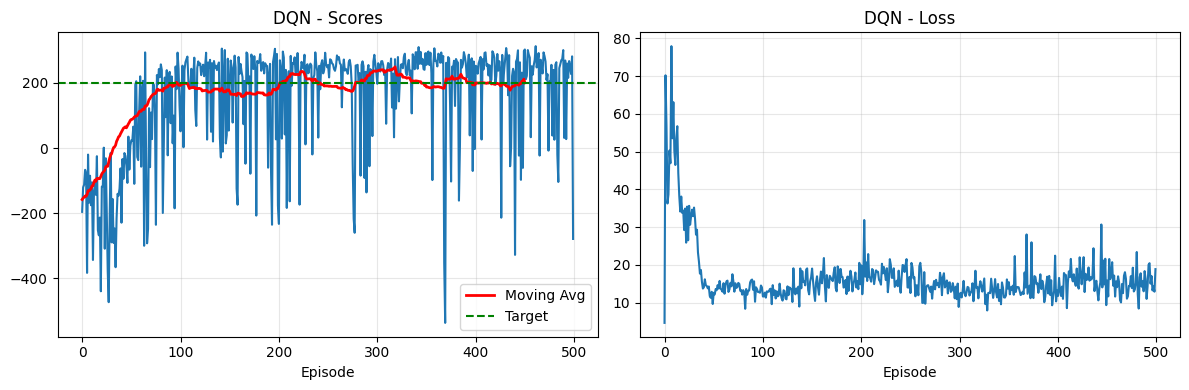


DQN Final Avg Score (last 50): 200.3


In [15]:
print("=" * 60)
print("TRAINING SIMPLE DQN ON LUNAR LANDER")
print("=" * 60)

try:
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
except Exception:
    env = gym.make("LunarLander-v2", render_mode="rgb_array")

env.action_space.seed(SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"State dim: {state_dim}, Action dim: {action_dim}\n")

# Create agent
dqn_agent = DQNAgent(state_dim, action_dim)

# Train
dqn_scores, dqn_losses = train_dqn(
    env,
    dqn_agent,
    num_episodes=500,
    max_steps=1000
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
video_dqn = save_agent_video(env, dqn_agent, filename="media/dqn.mp4")

axes[0].plot(dqn_scores)
axes[0].plot(
    np.convolve(dqn_scores, np.ones(50) / 50, mode="valid"),
    "r-",
    linewidth=2,
    label="Moving Avg"
)
axes[0].axhline(y=200, color="g", linestyle="--", label="Target")
axes[0].set_title("DQN - Scores")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dqn_losses)
axes[1].set_title("DQN - Loss")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDQN Final Avg Score (last 50): {np.mean(dqn_scores[-50:]):.1f}")

show_video(video_dqn, width=600)

# Double DQN (DDQN)

### The Problem We're Solving
Regular DQN uses the **same network** to pick the best action AND to evaluate it.
This causes **overestimation** — the agent thinks actions are better than they really are.

Think of it like grading your own test: you're probably too nice to yourself!

### The Solution: Split the Jobs
Double DQN uses **two networks**:
- **Online Network** → picks the best action (the student)
- **Target Network** → evaluates that action's value (the teacher)



### Hyperparameters
Same as DQN — no new hyperparameters needed!
- `gamma`: discount factor
- `epsilon`: exploration rate
- `epsilon_decay`: how fast we stop exploring
- `batch_size`: samples per update
- `target_update_freq`: how often to sync networks

### The Double DQN Update Step
This is where the magic happens:

1. Sample a batch from ReplayBuffer
2. Get current Q-values from **online network**
3. Find **best action** using online network  $\to a_\text{best} = \argmax Q_\text{online}(s')$
4. Get Q-values for those actions from **target network**  $\to Q_\text{target}(s', a_\text{best})$
5. Compute TD target: $y = r + \gamma \times Q_\text{target}(s', a_\text{best})$
6. Compute loss between online predictions and target
7. Optimize online network
8. Periodically update target network


In [16]:
class DDQNAgent(DQNAgent):
    """
    Double DQN extends DQN to reduce overestimation.
    
    The problem with standard DQN:
    - Uses max() which tends to overestimate Q-values
    
    Double DQN solution:
    - Use online network to SELECT the action
    - Use target network to EVALUATE the action
    
    This decouples selection from evaluation.
    """
    
    def update(self):
        """Update using Double DQN algorithm"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from replay buffer
        batch = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)
        
        # DOUBLE DQN Update
        
        # Current Q values: Q_online(s, a)
        current_q = self.q_network(states).gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)
        
        with torch.no_grad():
            # Step 1: Use ONLINE network to select best action
            next_actions = self.q_network(next_states).argmax(
                dim=1, keepdim=True
            )
            
            # Step 2: Use TARGET network to evaluate that action
            next_q = self.target_network(next_states).gather(
                1, next_actions
            ).squeeze(1)
            
            # Step 3: Compute target
            target_q = rewards + self.gamma * (1.0 - dones) * next_q
        
        # Compute loss and update
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network periodically
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING DOUBLE DQN ON LUNAR LANDER
State dim: 8, Action dim: 4

Episode 50/500 | Score: -110.6 | Avg: -124.7 | ε: 0.050
Episode 100/500 | Score: -122.4 | Avg: -74.2 | ε: 0.050
Episode 150/500 | Score: -84.8 | Avg: -13.2 | ε: 0.050
Episode 200/500 | Score: 231.3 | Avg: 3.9 | ε: 0.050
Episode 250/500 | Score: 234.4 | Avg: 53.5 | ε: 0.050
Episode 300/500 | Score: 246.5 | Avg: 208.5 | ε: 0.050
Episode 350/500 | Score: 292.0 | Avg: 221.0 | ε: 0.050
Episode 400/500 | Score: 254.5 | Avg: 232.1 | ε: 0.050
Episode 450/500 | Score: 4.0 | Avg: 241.7 | ε: 0.050
Episode 500/500 | Score: -298.6 | Avg: 226.3 | ε: 0.050


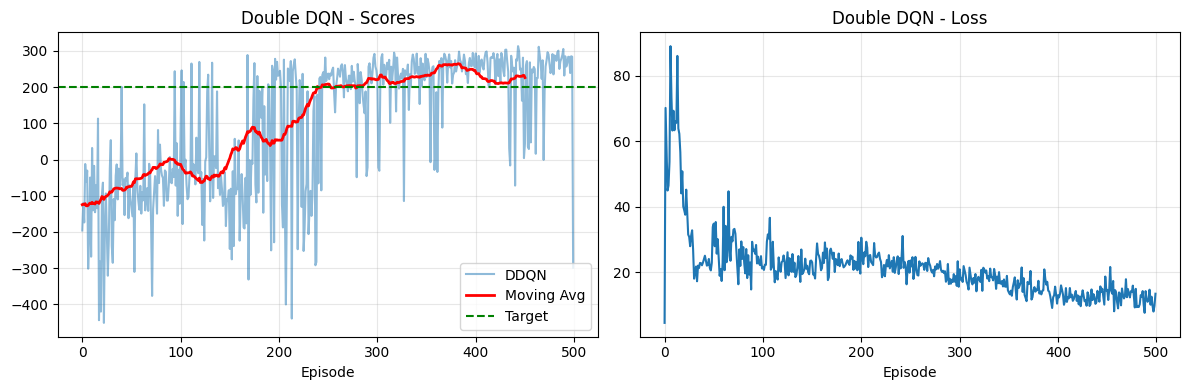


DDQN Final Avg Score (last 50): 226.3


In [17]:
print("=" * 60)
print("TRAINING DOUBLE DQN ON LUNAR LANDER")
print("=" * 60)

# Reset seeds for fair comparison
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    env2 = gym.make("LunarLander-v3", render_mode="rgb_array")
except Exception:
    env2 = gym.make("LunarLander-v2", render_mode="rgb_array")

env2.action_space.seed(SEED)

state_dim = env2.observation_space.shape[0]
action_dim = env2.action_space.n

print(f"State dim: {state_dim}, Action dim: {action_dim}\n")

# Create DDQN agent
ddqn_agent = DDQNAgent(state_dim, action_dim)

# Train
ddqn_scores, ddqn_losses = train_dqn(
    env2,
    ddqn_agent,
    num_episodes=500,
    max_steps=1000
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
video_ddqn = save_agent_video(env2, ddqn_agent, filename="media/ddqn.mp4")

axes[0].plot(ddqn_scores, alpha=0.5, label="DDQN")
axes[0].plot(
    np.convolve(ddqn_scores, np.ones(50) / 50, mode="valid"),
    "r-",
    linewidth=2,
    label="Moving Avg"
)
axes[0].axhline(y=200, color="g", linestyle="--", label="Target")
axes[0].set_title("Double DQN - Scores")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ddqn_losses)
axes[1].set_title("Double DQN - Loss")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDDQN Final Avg Score (last 50): {np.mean(ddqn_scores[-50:]):.1f}")

show_video(video_ddqn, width=600)

# Dueling DQN

### DuelingQNetwork — Splitting Value and Advantage

Instead of estimating $Q(s,a)$ directly, we break it into two parts:


- **$V(s)$** = How good is it to be in this state? (regardless of action)
- **$A(s,a)$** = How much better is action $a$ compared to other actions?

### Why Is This Better?
Imagine you're watching a movie:
- Some scenes are exciting regardless of what happens → **$V(s)$** is high
- The specific action matters more in tense scenes → **$A(s,a)$** carries more weight

By separating them, the network can learn **$V(s)$** directly without averaging across all actions.



### The Formula
We don't use $Q = V + A$ directly. Instead:

$$ Q(s,a) = V(s) + A(s,a) - mean(A(s,:))$$


In [18]:
# =============================================================================
# Dueling DQN
# Architecture that separates value and advantage estimation
# =============================================================================

class DuelingQNetwork(nn.Module):
    """
    Dueling DQN separates the value function into two streams:
    
    Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
    
    - V(s): Value of being in state s
    - A(s,a): Advantage of taking action a
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        super(DuelingQNetwork, self).__init__()
        self.action_dim = action_dim
        
        # Shared feature extractor
        self.features = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        
        # Value stream: V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
        # Advantage stream: A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    
    def forward(self, x):
        features = self.features(x)
        
        # Get value and advantage
        value = self.value_stream(features)          # Shape: [batch_size, 1]
        advantage = self.advantage_stream(features) # Shape: [batch_size, action_dim]
        
        # Combine: Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        
        return q_values

In [19]:
class DuelingDQNAgent:
    """
    Dueling DQN uses the dueling network architecture.
    The update rule is DDQN:
    - Online network selects the next action
    - Target network evaluates that selected action
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # Hyperparameters
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995
        self.batch_size = 64
        self.target_update_freq = 500
        self.action_dim = action_dim
        
        # Networks: Dueling architecture
        self.q_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network = DuelingQNetwork(state_dim, action_dim).to(device)

        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=1e-3)

        # Use a large replay buffer for stable training
        self.memory = ReplayBuffer(capacity=100_000)

        self.steps = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            action = q_values.argmax(dim=1).item()
        
        return action
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        if len(self.memory) < self.batch_size:
            return None
        
        batch = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)
        
        # Current Q values: Q_online(s, a)
        current_q = self.q_network(states).gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)
        
        # Target Q values using DDQN update rule
        with torch.no_grad():
            # Online network selects best next action
            next_actions = self.q_network(next_states).argmax(
                dim=1, keepdim=True
            )
            
            # Target network evaluates that action
            next_q = self.target_network(next_states).gather(
                1, next_actions
            ).squeeze(1)
            
            # DDQN target
            target_q = rewards + self.gamma * (1.0 - dones) * next_q
        
        # Compute loss
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING DUELING DQN ON LUNAR LANDER
State dim: 8, Action dim: 4

Episode 50/500 | Score: -11.2 | Avg: -98.2 | ε: 0.050
Episode 100/500 | Score: 251.4 | Avg: 75.4 | ε: 0.050
Episode 150/500 | Score: 197.0 | Avg: 145.3 | ε: 0.050
Episode 200/500 | Score: -120.5 | Avg: 49.1 | ε: 0.050
Episode 250/500 | Score: 245.0 | Avg: 166.6 | ε: 0.050
Episode 300/500 | Score: 231.7 | Avg: 203.4 | ε: 0.050
Episode 350/500 | Score: 232.4 | Avg: 148.7 | ε: 0.050
Episode 400/500 | Score: 280.2 | Avg: 231.0 | ε: 0.050
Episode 450/500 | Score: 293.3 | Avg: 257.5 | ε: 0.050
Episode 500/500 | Score: 0.4 | Avg: 226.5 | ε: 0.050


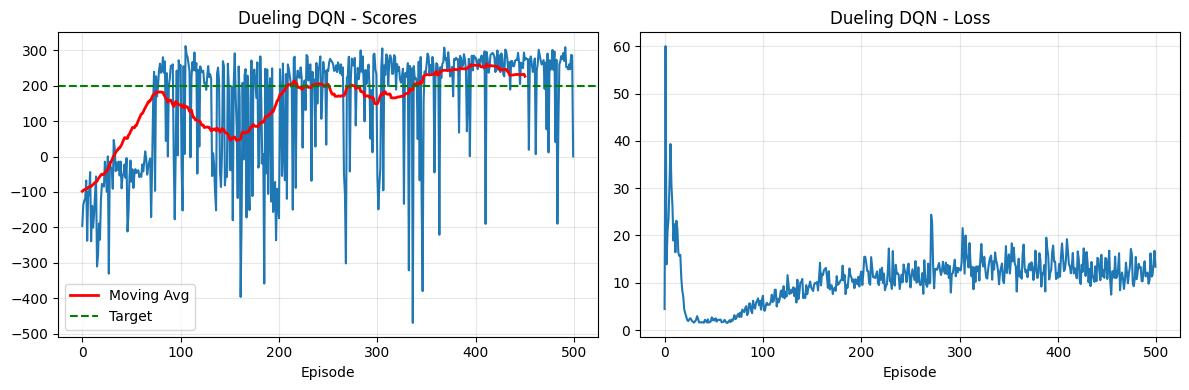


Dueling DQN Final Avg Score (last 50): 226.5


In [20]:
print("=" * 60)
print("TRAINING DUELING DQN ON LUNAR LANDER")
print("=" * 60)

# Reset seeds for fair comparison
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    env3 = gym.make("LunarLander-v3", render_mode="rgb_array")
except Exception:
    env3 = gym.make("LunarLander-v2", render_mode="rgb_array")

env3.action_space.seed(SEED)

state_dim = env3.observation_space.shape[0]
action_dim = env3.action_space.n

print(f"State dim: {state_dim}, Action dim: {action_dim}\n")

# Create agent
dueling_agent = DuelingDQNAgent(state_dim, action_dim)

# Train
dueling_scores, dueling_losses = train_dqn(
    env3,
    dueling_agent,
    num_episodes=500,
    max_steps=1000
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
video_duelingdqn = save_agent_video(
    env3,
    dueling_agent,
    filename="media/duelingdqn.mp4"
)

axes[0].plot(dueling_scores)
axes[0].plot(
    np.convolve(dueling_scores, np.ones(50) / 50, mode="valid"),
    "r-",
    linewidth=2,
    label="Moving Avg"
)
axes[0].axhline(y=200, color="g", linestyle="--", label="Target")
axes[0].set_title("Dueling DQN - Scores")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dueling_losses)
axes[1].set_title("Dueling DQN - Loss")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDueling DQN Final Avg Score (last 50): {np.mean(dueling_scores[-50:]):.1f}")

show_video(video_duelingdqn, width=600)

# Prioritized Experience Replay (PER)


### SumTree — The Priority Organizer

### Why Do We Need It?
Regular replay buffer picks experiences **randomly**.
But some experiences teach us more than others!

Experiences with **high TD error** (big surprise) are more valuable.
We want to pick those more often.

### How Does SumTree Work?
Think of it like a **binary tree** where:
- Each **leaf** = one experience with a priority score
- Each **internal node** = sum of its children


In [32]:
class SumTree:
    """
    Sum Tree data structure for efficient prioritized sampling.
    """
    
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float32)
        self.data = np.empty(capacity, dtype=object)
        self.write_idx = 0
        self.size = 0
    
    @property
    def total_priority(self):
        return self.tree[0]
    
    def add(self, priority: float, transition: Transition):
        idx = self.write_idx + self.capacity - 1
        
        self.data[self.write_idx] = transition
        self.update(idx, priority)
        
        self.write_idx = (self.write_idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def update(self, idx: int, priority: float):
        priority = float(priority)
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        
        while idx != 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change
    
    def sample(self, batch_size: int):
        batch = []
        total = self.total_priority
        
        if total <= 0:
            raise ValueError("Cannot sample because total priority is zero.")
        
        segment = total / batch_size
        
        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            
            # random.random() avoids sampling exactly the upper endpoint
            r = a + random.random() * (b - a)
            
            idx = self._find_leaf(0, r)
            data_idx = idx - self.capacity + 1
            
            transition = self.data[data_idx]
            priority = self.tree[idx]
            
            # Safety fallback: avoid empty zero-priority leaves
            while transition is None or priority <= 0:
                r = random.random() * total
                idx = self._find_leaf(0, r)
                data_idx = idx - self.capacity + 1
                transition = self.data[data_idx]
                priority = self.tree[idx]
            
            batch.append((idx, priority, transition))
        
        return batch
    
    def _find_leaf(self, idx: int, r: float) -> int:
        left = 2 * idx + 1
        right = left + 1
        
        if left >= len(self.tree):
            return idx
        
        # Use < instead of <= to avoid going into zero-priority branches
        if r < self.tree[left]:
            return self._find_leaf(left, r)
        else:
            return self._find_leaf(right, r - self.tree[left])
    
    def __len__(self):
        return self.size

### The Problem with Uniform Sampling
Regular buffer treats all experiences equally.
But if you already know something well, reviewing it is a waste of time!

### The Solution: Priority-Based Sampling
We sample experiences with probability proportional to their TD error:

+ ${P}(\text{experience}) \propto  |\text{TD error}|^\alpha $

- $\alpha = 0 \to$ uniform sampling (like regular buffer)
- $\alpha = 1 \to$ full prioritization (only important experiences)

### Importance Sampling (IS) Weights
Prioritization changes the distribution → introduces **bias**.
We fix this with IS weights:
+ $w = (N × \mathbb{P}(i))^{-\beta}$

- $\beta = 0 \to$ no correction (fast but biased)
- $\beta = 1 \to$ full correction (unbiased but higher variance)


In [33]:
class PrioritizedReplayBuffer:
    """
    Prioritized Experience Replay Buffer
    """
    
    def __init__(self, capacity: int = 100, alpha: float = 0.6, beta: float = 0.4):
        self.capacity = capacity
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = 1e-4
        self.epsilon = 1e-6
        
        self.tree = SumTree(capacity)
        self.max_priority = 1.0
    
    def push(self, *args):
        transition = Transition(*args)
        self.tree.add(self.max_priority, transition)
    
    def sample(self, batch_size: int):
        samples = self.tree.sample(batch_size)
        
        indices = []
        priorities = []
        transitions = []
        
        for idx, priority, transition in samples:
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)
        
        priorities = np.array(priorities, dtype=np.float32)
        
        # Avoid zero probabilities
        probs = priorities / self.tree.total_priority
        probs = np.maximum(probs, 1e-8)
        
        weights = (self.tree.size * probs) ** (-self.beta)
        weights = weights / weights.max()
        weights = weights.astype(np.float32)
        
        states = np.array([t.state for t in transitions])
        actions = np.array([t.action for t in transitions])
        rewards = np.array([t.reward for t in transitions])
        next_states = np.array([t.next_state for t in transitions])
        dones = np.array([t.done for t in transitions])
        
        return states, actions, rewards, next_states, dones, weights, indices
    
    def update_priorities(self, indices: list, td_errors: np.ndarray):
        for idx, error in zip(indices, td_errors):
            priority = (abs(error) + self.epsilon) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)
    
    def __len__(self):
        return len(self.tree)

In [34]:
class PERDQNAgent:
    """
    DQN with Prioritized Experience Replay.
    Uses Double DQN target rule.
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995
        self.batch_size = 64
        self.target_update_freq = 500
        self.action_dim = action_dim
        
        # PER parameters
        self.alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 1e-4
        
        # Networks
        self.q_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=1e-3)
        
        # Prioritized Replay Buffer
        self.memory = PrioritizedReplayBuffer(
            capacity=50_000,
            alpha=self.alpha,
            beta=self.beta
        )
        
        self.steps = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            action = q_values.argmax(dim=1).item()
        
        return action
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """PER DQN update with importance sampling"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Keep buffer beta synced with agent beta
        self.memory.beta = self.beta
        
        # Sample from prioritized buffer
        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(
            self.batch_size
        )
        
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)
        weights_tensor = torch.FloatTensor(weights).to(device)
        
        # Current Q values
        current_q = self.q_network(states).gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)
        
        # Target Q values: Double DQN style
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(
                dim=1, keepdim=True
            )
            
            next_q = self.target_network(next_states).gather(
                1, next_actions
            ).squeeze(1)
            
            target_q = rewards + self.gamma * (1.0 - dones) * next_q
        
        # Compute TD errors for priority update
        td_errors = target_q - current_q
        
        # Weighted loss using importance sampling weights
        loss = (weights_tensor * td_errors.pow(2)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update priorities after learning
        self.memory.update_priorities(
            indices,
            td_errors.detach().abs().cpu().numpy()
        )
        
        # Increment beta toward 1.0
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING PER DQN ON LUNAR LANDER
Episode 50/500 | Score: -8.8 | Avg: -194.4 | ε: 0.050
Episode 100/500 | Score: -73.5 | Avg: -49.7 | ε: 0.050
Episode 150/500 | Score: 4.5 | Avg: -30.3 | ε: 0.050
Episode 200/500 | Score: -31.5 | Avg: 12.9 | ε: 0.050
Episode 250/500 | Score: 234.5 | Avg: 59.0 | ε: 0.050
Episode 300/500 | Score: 248.8 | Avg: 59.2 | ε: 0.050
Episode 350/500 | Score: 264.4 | Avg: 163.8 | ε: 0.050
Episode 400/500 | Score: 278.2 | Avg: 185.4 | ε: 0.050
Episode 450/500 | Score: 266.5 | Avg: 164.7 | ε: 0.050
Episode 500/500 | Score: -234.6 | Avg: 136.5 | ε: 0.050


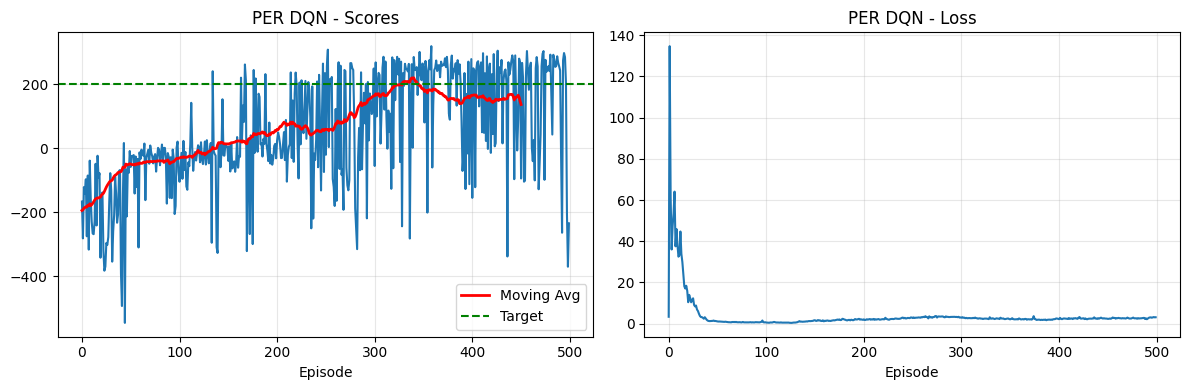


PER DQN Final Avg Score (last 50): 136.5


In [35]:
print("=" * 60)
print("TRAINING PER DQN ON LUNAR LANDER")
print("=" * 60)

# Reset seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    env4 = gym.make("LunarLander-v3", render_mode="rgb_array")
except Exception:
    env4 = gym.make("LunarLander-v2", render_mode="rgb_array")

env4.action_space.seed(SEED)

state_dim = env4.observation_space.shape[0]
action_dim = env4.action_space.n

per_agent = PERDQNAgent(state_dim, action_dim)

per_scores, per_losses = train_dqn(
    env4,
    per_agent,
    num_episodes=500,
    max_steps=1000
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
video_perdqn = save_agent_video(env4, per_agent, filename="media/perdqn.mp4")

axes[0].plot(per_scores)
axes[0].plot(
    np.convolve(per_scores, np.ones(50) / 50, mode="valid"),
    "r-",
    linewidth=2,
    label="Moving Avg"
)
axes[0].axhline(y=200, color="g", linestyle="--", label="Target")
axes[0].set_title("PER DQN - Scores")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(per_losses)
axes[1].set_title("PER DQN - Loss")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPER DQN Final Avg Score (last 50): {np.mean(per_scores[-50:]):.1f}")

show_video(video_perdqn, width=600)

# Half-Rainbow DQN (Double + Dueling + PER)

Rainbow DQN (Hessel et al., 2018) combined **6 different techniques**.
In this section we implement the 3 mentioned ones.


### Your Task
- Combine `DuelingQNetwork` architecture
- Use `PrioritizedReplayBuffer` for storage
- Implement Double DQN update logic
- Make sure priorities are updated after each learning step


In [36]:
# =============================================================================
# Double DQN + Dueling Architecture + Prioritized Experience Replay
# =============================================================================

class CombinedDQNAgent:
    """
    1. Double DQN - Reduces overestimation
    2. Dueling Network - Better value estimation
    3. Prioritized Experience Replay - Better sample efficiency
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # Hyperparameters
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.9995
        self.batch_size = 64
        self.target_update_freq = 500
        self.action_dim = action_dim
        
        # PER parameters
        self.alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 1e-4
        
        # Networks: Dueling architecture
        self.q_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network = DuelingQNetwork(state_dim, action_dim).to(device)

        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=1e-3)
        
        # Prioritized Replay Buffer
        self.memory = PrioritizedReplayBuffer(
            capacity=100_000,
            alpha=self.alpha,
            beta=self.beta
        )

        self.steps = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            action = q_values.argmax(dim=1).item()
        
        return action
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """Combined update: Double DQN + Dueling + PER"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Keep buffer beta synced with agent beta
        self.memory.beta = self.beta
        
        # Sample from prioritized buffer
        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(
            self.batch_size
        )
        
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)
        weights_tensor = torch.FloatTensor(weights).to(device)
        
        # Current Q values: Q_online(s, a)
        current_q = self.q_network(states).gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)
        
        # Target Q values: Double DQN target
        with torch.no_grad():
            # Online network selects action
            next_actions = self.q_network(next_states).argmax(
                dim=1, keepdim=True
            )
            
            # Target network evaluates selected action
            next_q = self.target_network(next_states).gather(
                1, next_actions
            ).squeeze(1)
            
            target_q = rewards + self.gamma * (1.0 - dones) * next_q

        # TD errors for PER
        td_errors = target_q - current_q
        
        # Weighted loss with importance sampling
        loss = (weights_tensor * td_errors.pow(2)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update priorities
        self.memory.update_priorities(
            indices,
            td_errors.detach().abs().cpu().numpy()
        )
        
        # Update beta
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING HALF RAINBOW DQN (Double + Dueling + PER)
Episode 50/500 | Score: -160.2 | Avg: -150.9 | ε: 0.050
Episode 100/500 | Score: -78.2 | Avg: -95.4 | ε: 0.050
Episode 150/500 | Score: 282.5 | Avg: 22.6 | ε: 0.050
Episode 200/500 | Score: -123.0 | Avg: 54.7 | ε: 0.050
Episode 250/500 | Score: 231.3 | Avg: 155.9 | ε: 0.050
Episode 300/500 | Score: 112.9 | Avg: 140.7 | ε: 0.050
Episode 350/500 | Score: 231.2 | Avg: 196.6 | ε: 0.050
Episode 400/500 | Score: 246.1 | Avg: 126.9 | ε: 0.050
Episode 450/500 | Score: 269.9 | Avg: 150.9 | ε: 0.050
Episode 500/500 | Score: -155.8 | Avg: 112.3 | ε: 0.050


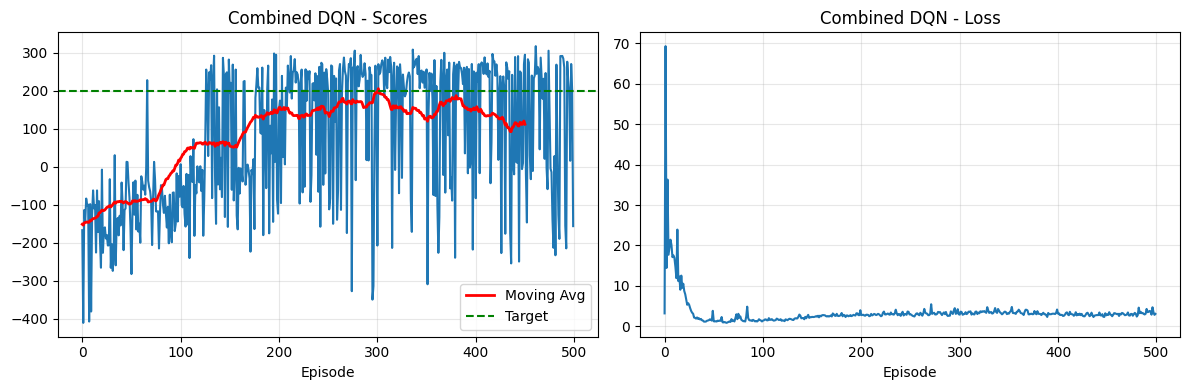


Combined DQN Final Avg Score (last 50): 112.3


In [37]:
print("=" * 60)
print("TRAINING HALF RAINBOW DQN (Double + Dueling + PER)")
print("=" * 60)

# Reset seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    env5 = gym.make("LunarLander-v3", render_mode="rgb_array")
except Exception:
    env5 = gym.make("LunarLander-v2", render_mode="rgb_array")

env5.action_space.seed(SEED)

state_dim = env5.observation_space.shape[0]
action_dim = env5.action_space.n

combined_agent = CombinedDQNAgent(state_dim, action_dim)

combined_scores, combined_losses = train_dqn(
    env5,
    combined_agent,
    num_episodes=500,
    max_steps=1000
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
video_halfrainbow = save_agent_video(
    env5,
    combined_agent,
    filename="media/halfrainbow.mp4"
)

axes[0].plot(combined_scores)
axes[0].plot(
    np.convolve(combined_scores, np.ones(50) / 50, mode="valid"),
    "r-",
    linewidth=2,
    label="Moving Avg"
)
axes[0].axhline(y=200, color="g", linestyle="--", label="Target")
axes[0].set_title("Combined DQN - Scores")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(combined_losses)
axes[1].set_title("Combined DQN - Loss")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCombined DQN Final Avg Score (last 50): {np.mean(combined_scores[-50:]):.1f}")

show_video(video_halfrainbow, width=600)

# Last Task: Final Comparison - All Methods


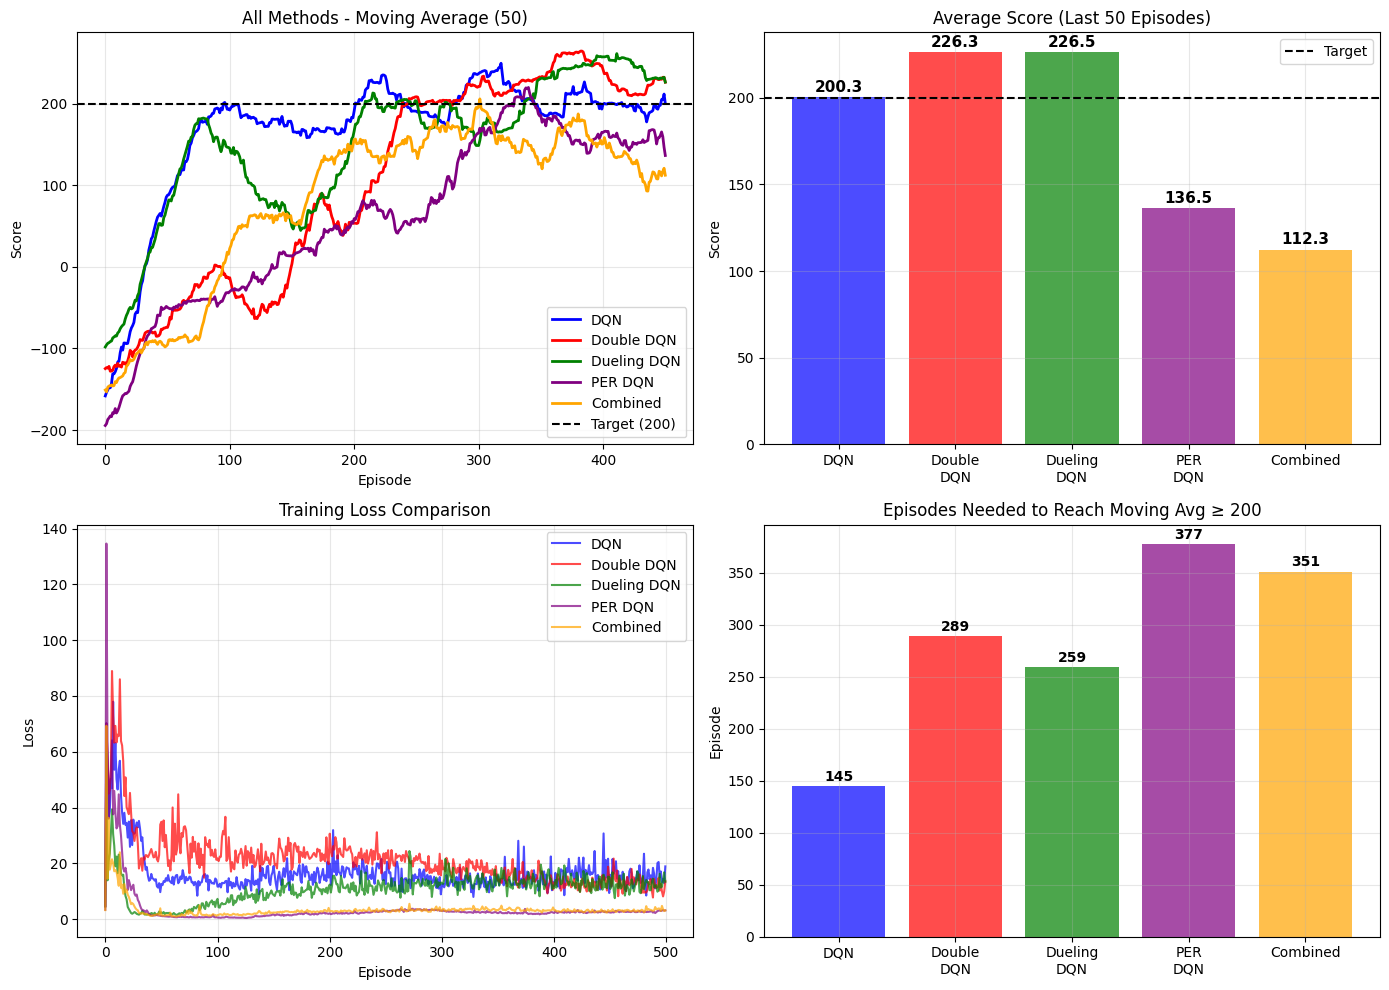


FINAL SUMMARY - ALL METHODS COMPARISON
Method               Avg Score (last 50)       Solved Episode       Status                   
----------------------------------------------------------------------
DQN                  200.3                     145                  Basic                    
Double DQN           226.3                     289                  Reduced overestimation   
Dueling DQN          226.5                     259                  Better V(s) estimation   
PER DQN              136.5                     377                  Better sampling          
Combined             112.3                     351                  All techniques           
Target Score: 200 solved


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

window = 50

# Calculate moving averages
dqn_ma = np.convolve(dqn_scores, np.ones(window) / window, mode="valid")
ddqn_ma = np.convolve(ddqn_scores, np.ones(window) / window, mode="valid")
dueling_ma = np.convolve(dueling_scores, np.ones(window) / window, mode="valid")
per_ma = np.convolve(per_scores, np.ones(window) / window, mode="valid")
combined_ma = np.convolve(combined_scores, np.ones(window) / window, mode="valid")

# Plot 1: All moving averages
axes[0, 0].plot(dqn_ma, color="blue", linewidth=2, label="DQN")
axes[0, 0].plot(ddqn_ma, color="red", linewidth=2, label="Double DQN")
axes[0, 0].plot(dueling_ma, color="green", linewidth=2, label="Dueling DQN")
axes[0, 0].plot(per_ma, color="purple", linewidth=2, label="PER DQN")
axes[0, 0].plot(combined_ma, color="orange", linewidth=2, label="Combined")
axes[0, 0].axhline(y=200, color="black", linestyle="--", label="Target (200)")
axes[0, 0].set_title("All Methods - Moving Average (50)")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Final scores bar chart
labels = ["DQN", "Double\nDQN", "Dueling\nDQN", "PER\nDQN", "Combined"]
final_scores = [
    np.mean(dqn_scores[-50:]),
    np.mean(ddqn_scores[-50:]),
    np.mean(dueling_scores[-50:]),
    np.mean(per_scores[-50:]),
    np.mean(combined_scores[-50:])
]
colors = ["blue", "red", "green", "purple", "orange"]

bars = axes[0, 1].bar(labels, final_scores, color=colors, alpha=0.7)
axes[0, 1].axhline(y=200, color="black", linestyle="--", label="Target")
axes[0, 1].set_title("Average Score (Last 50 Episodes)")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for bar, score in zip(bars, final_scores):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{score:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Plot 3: Loss comparison
axes[1, 0].plot(dqn_losses, color="blue", alpha=0.7, label="DQN")
axes[1, 0].plot(ddqn_losses, color="red", alpha=0.7, label="Double DQN")
axes[1, 0].plot(dueling_losses, color="green", alpha=0.7, label="Dueling DQN")
axes[1, 0].plot(per_losses, color="purple", alpha=0.7, label="PER DQN")
axes[1, 0].plot(combined_losses, color="orange", alpha=0.7, label="Combined")
axes[1, 0].set_title("Training Loss Comparison")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Episodes to solve
def first_solved_episode(scores, window=50, threshold=200):
    ma = np.convolve(scores, np.ones(window) / window, mode="valid")
    solved = np.where(ma >= threshold)[0]
    if len(solved) == 0:
        return None
    return solved[0] + window

solve_episodes = [
    first_solved_episode(dqn_scores),
    first_solved_episode(ddqn_scores),
    first_solved_episode(dueling_scores),
    first_solved_episode(per_scores),
    first_solved_episode(combined_scores)
]

plot_values = [
    ep if ep is not None else len(dqn_scores)
    for ep in solve_episodes
]

bars = axes[1, 1].bar(labels, plot_values, color=colors, alpha=0.7)
axes[1, 1].set_title("Episodes Needed to Reach Moving Avg ≥ 200")
axes[1, 1].set_ylabel("Episode")
axes[1, 1].grid(True, alpha=0.3)

for bar, ep in zip(bars, solve_episodes):
    text = str(ep) if ep is not None else "Not solved"
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        text,
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "=" * 70)
print("FINAL SUMMARY - ALL METHODS COMPARISON")
print("=" * 70)
print(f"{'Method':<20} {'Avg Score (last 50)':<25} {'Solved Episode':<20} {'Status':<25}")
print("-" * 70)

methods = [
    ("DQN", dqn_scores, "Basic"),
    ("Double DQN", ddqn_scores, "Reduced overestimation"),
    ("Dueling DQN", dueling_scores, "Better V(s) estimation"),
    ("PER DQN", per_scores, "Better sampling"),
    ("Combined", combined_scores, "All techniques")
]

for name, scores, status in methods:
    avg_score = np.mean(scores[-50:])
    solved_ep = first_solved_episode(scores)
    solved_text = str(solved_ep) if solved_ep is not None else "Not solved"
    print(f"{name:<20} {avg_score:<25.1f} {solved_text:<20} {status:<25}")

print("=" * 70)
print("Target Score: 200 solved")